In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn import metrics
%matplotlib inline

In [2]:
path = 'heart_disease_data.csv'
data = pd.read_csv(path)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
models = {
    "LR": LogisticRegression(),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(max_depth= 8),
    "SVM": SVC(),
    "KNN" : KNeighborsClassifier() 
}

In [4]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

## Cross-validation with MI

In [5]:
x = StandardScaler().fit_transform(data[['chol','thalach', 'oldpeak', 'ca', 'cp', 'thal', 'trestbps']])
x = np.asarray(x)
y = np.asarray(data['target'])

perf_resualt = []
for name, model in models.items():
    results = cross_validate(model, x, y, cv=9, scoring=scoring)
    
    perf_resualt.append({
        'Accuracy': round(results['test_accuracy'].mean()*100, 2),
        'Precision': round(results['test_precision'].mean()*100, 2),
        'Recall': round(results['test_recall'].mean()*100, 2),
        'F1 Score': round(results['test_f1'].mean()*100, 2)
    })

C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be 

In [6]:
results_df = pd.DataFrame(perf_resualt , index = ['LR', 'NB', 'DT', 'SVM', 'KNN'])
results_df

,Accuracy,Precision,Recall,F1 Score
LR,82.49,83.13,81.91,82.03
NB,83.15,83.43,82.78,82.85
DT,92.07,92.18,91.95,91.99
SVM,85.30,85.63,84.84,85.00
KNN,84.64,85.20,84.13,84.29


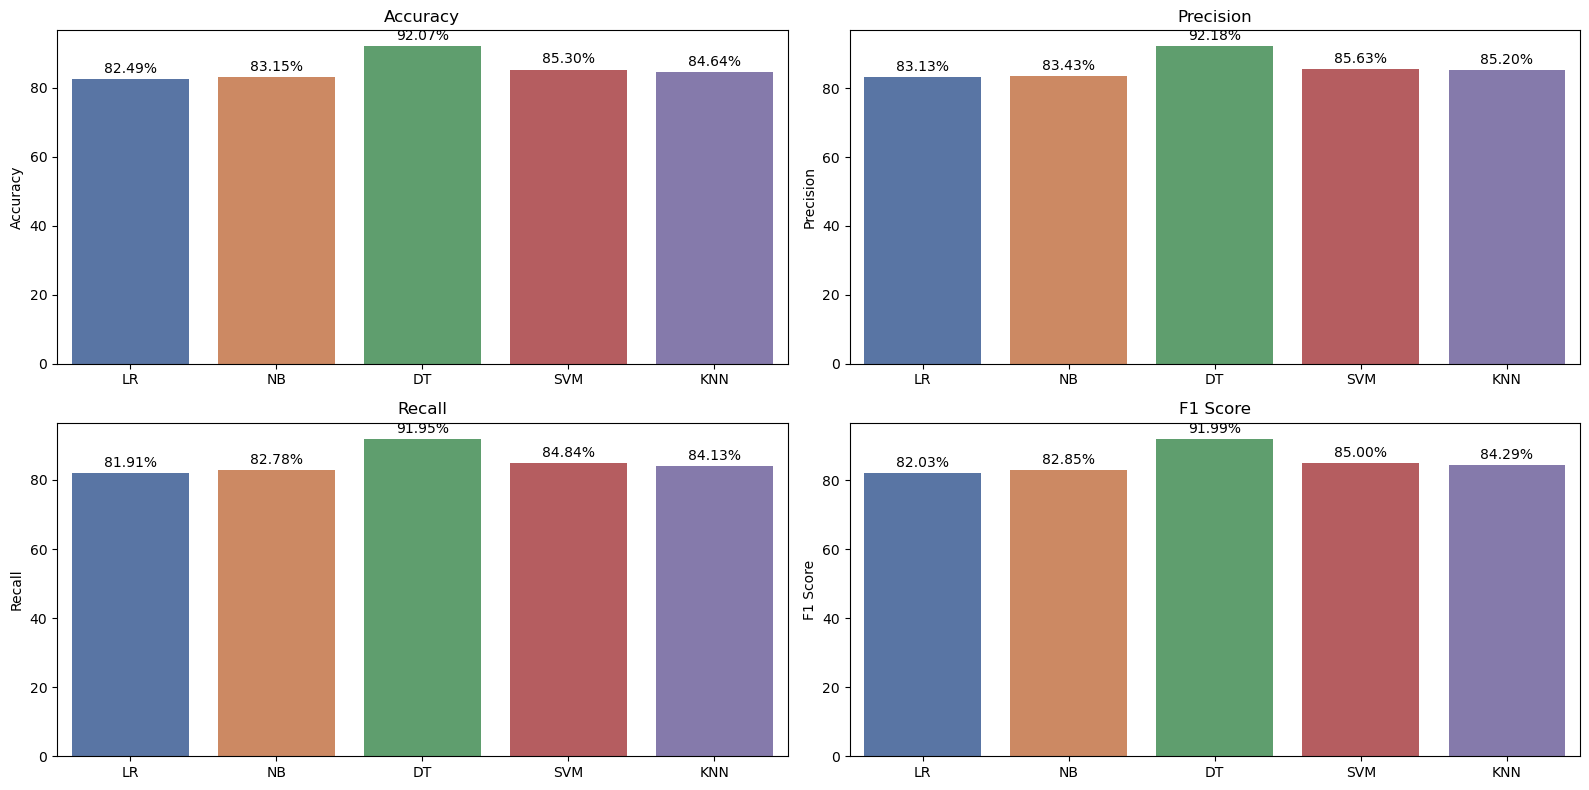

In [7]:
import math
models = results_df.index.values
per_meaures = results_df.columns[:]

n_cols = 2
n_rows = math.ceil(len(per_meaures) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(per_meaures, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(x=models, y=results_df[col], palette="deep")
    
    x = range(len(models))
    y = results_df[col].values
    for j in x:
        plt.text(j, y[j] + max(y)*0.01,  # وضع النص أعلى البار
                 "{:.2f}%".format(y[j]),
                 ha='center', va='bottom',
                 color="black",
                 fontsize=10)

    plt.title(col)
    plt.tight_layout()  

plt.show()

## Cross-validation with RFE

In [8]:
models = {
    "LR": LogisticRegression(),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(max_depth= 8),
    "SVM": SVC(),
    "KNN" : KNeighborsClassifier() 
}

x = StandardScaler().fit_transform(data[['sex','cp', 'exang', 'oldpeak', 'slope', 'ca', 'thal']])
x = np.asarray(x)
y = np.asarray(data['target'])

perf_resualt = []
for name, model in models.items():
    results = cross_validate(model, x, y, cv=9, scoring=scoring)
    
    perf_resualt.append({
        'Accuracy': round(results['test_accuracy'].mean()*100, 2),
        'Precision': round(results['test_precision'].mean()*100, 2),
        'Recall': round(results['test_recall'].mean()*100, 2),
        'F1 Score': round(results['test_f1'].mean()*100, 2)
    })

C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be 

In [9]:
results_df = pd.DataFrame(perf_resualt , index = ['LR', 'NB', 'DT', 'SVM', 'KNN'])
results_df

,Accuracy,Precision,Recall,F1 Score
LR,83.31,83.72,82.79,82.91
NB,82.82,83.03,82.45,82.50
DT,91.09,91.27,91.03,90.99
SVM,86.46,87.15,85.91,86.14
KNN,85.30,85.48,84.99,85.10


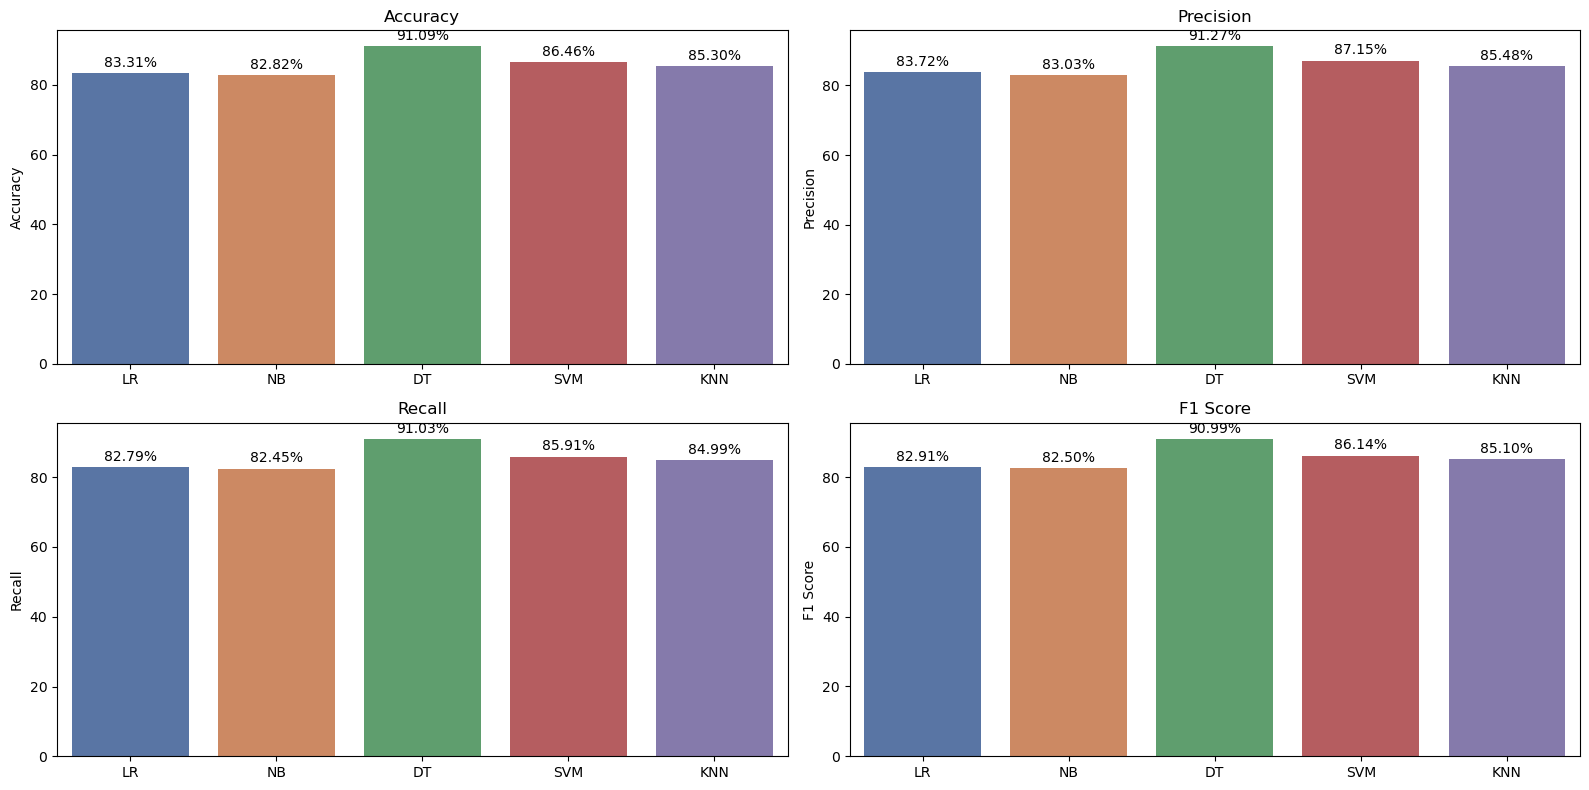

In [10]:
import math
models = results_df.index.values
per_meaures = results_df.columns[:]

n_cols = 2
n_rows = math.ceil(len(per_meaures) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(per_meaures, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(x=models, y=results_df[col], palette="deep")
    
    x = range(len(models))
    y = results_df[col].values
    for j in x:
        plt.text(j, y[j] + max(y)*0.01,  # وضع النص أعلى البار
                 "{:.2f}%".format(y[j]),
                 ha='center', va='bottom',
                 color="black",
                 fontsize=10)

    plt.title(col)
    plt.tight_layout()  

plt.show()